# Montréal Gas Price — Notebook 1: Daily Dataset Build
**Sources:**
- Gas prices: Kalibrate xlsx files (2016–2026), city = MONTRÉAL
- WTI crude oil: FRED series `DCOILWTICO` (USD/barrel, daily)
- CAD/USD rate: FRED series `DEXCAUS` (USD per 1 CAD, daily)

**Output:** `montreal_gas_features_daily.csv` — merged daily dataset ready for feature engineering

**Next:** Notebook 2 — Feature Engineering

## 0. Install & import

In [1]:
import sys
!{sys.executable} -m pip install pandas numpy matplotlib seaborn requests openpyxl


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: pip3.13 install --upgrade pip


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import requests
import os
import warnings
from datetime import datetime

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (14, 4)
print('Ready.')

Ready.


## 1. Download latest Kalibrate data

Historical files (2016–2025) are already saved in `/Data`.
We download only the current year's file automatically from the public Kalibrate URL.
The URL pattern is predictable — the year is injected dynamically.

In [3]:
DATA_DIR     = '../Data'
PLOTS_DIR    = '../plots'
DATA_OUT_DIR = '../Data'
CURRENT_YEAR = datetime.now().year
KALIBRATE_URL = (
    'https://charting.kalibrate.com/WPPS/Unleaded/'
    'Retail%20(Incl.%20Tax)/DAILY/{year}/'
    'Unleaded_Retail%20(Incl.%20Tax)_DAILY_{year}.xlsx'
)

def download_kalibrate(year):
    """Download Kalibrate Excel file for the given year into /Data."""
    url      = KALIBRATE_URL.format(year=year)
    out_path = os.path.join(DATA_DIR, f'Daily{year}.xlsx')
    print(f'Downloading {year} data from Kalibrate...')
    response = requests.get(url, timeout=30)
    response.raise_for_status()
    with open(out_path, 'wb') as f:
        f.write(response.content)
    print(f'Saved: {out_path}  ({len(response.content) / 1024:.1f} KB)')

# Download current year only — historical files are already in /Data
download_kalibrate(CURRENT_YEAR)

Saved: ../Data/Daily2026.xlsx  (98.4 KB)


## 2. Parse Kalibrate xlsx files → daily Montréal gas prices

Each year's Excel file has a slightly different layout:
- **2016**: dates in row 0, city data from row 1
- **2017–2026**: dates in row 2, city data from row 3

We handle both layouts and apply edge case handling for missing dates and prices.

In [4]:
YEARS = range(2016, CURRENT_YEAR + 1)
CITY  = 'MONTR'

def parse_all_years(years):
    """
    Read all Kalibrate xlsx files and return a daily DataFrame
    of Montréal retail gas prices.
    """
    records     = []
    prev_date   = None
    prev_prices = []

    for year in years:
        path = f'{DATA_DIR}/Daily{year}.xlsx'
        if not os.path.exists(path):
            print(f'  WARNING: {path} not found — skipping {year}')
            continue

        raw = pd.read_excel(path, header=None)

        # Layout differs between 2016 and all other years
        if year == 2016:
            date_row = raw.iloc[0, 1:].values
            df_raw   = raw.iloc[1:, :].set_index(0)
        else:
            date_row = raw.iloc[2, 1:].values
            df_raw   = raw.iloc[3:, :].set_index(0)

        # Find the Montréal row
        montreal_row = df_raw[df_raw.index.str.contains(CITY, na=False, case=False)]
        prices       = montreal_row.iloc[0].values

        for d, p in zip(date_row, prices):
            # Edge case: missing date
            try:
                current_date = pd.to_datetime(f'{d}/{year}', format='%m/%d/%Y')
            except Exception:
                if prev_date is None:
                    continue
                current_date = prev_date + pd.Timedelta(days=1)

            # Edge case: missing price — use rolling average of last 10 prices
            if pd.isna(p):
                if len(prev_prices) == 0:
                    continue
                current_price = float(np.mean(prev_prices))
            else:
                current_price = float(p)

            records.append({'date': current_date, 'gas_price': current_price})
            prev_date = current_date
            prev_prices.append(current_price)
            if len(prev_prices) > 10:
                prev_prices.pop(0)

    gas = (
        pd.DataFrame(records)
        .drop_duplicates('date')
        .set_index('date')
        .sort_index()
    )
    gas = gas[(gas.index >= '2016-07-01') & (gas.index <= pd.Timestamp.today().normalize())]
    return gas


gas = parse_all_years(YEARS)
print(f'Gas prices: {len(gas):,} rows  {gas.index.min().date()} → {gas.index.max().date()}')
gas

Gas prices: 2,547 rows  2016-07-01 → 2026-04-03


,gas_price
date,
2016-07-01,117.90
2016-07-04,110.50
2016-07-05,109.30
2016-07-06,108.20
2016-07-07,107.10
...,...
2026-03-30,192.70
2026-03-31,193.10
2026-04-01,195.30


## 3. Fetch WTI crude & CAD/USD from FRED

We fetch both series directly from the FRED API — no manual download needed.
- **WTI crude oil** (`DCOILWTICO`): USD per barrel, daily
- **CAD/USD exchange rate** (`DEXCAUS`): USD per 1 CAD, daily


In [5]:
FRED_API_KEY = '30e324966282328b1d03b97b95ef9b1f'
START_DATE   = '2016-07-01'

def fetch_fred_series(series_id, col_name):
    """Fetch a FRED series and return a named daily Series."""
    url = (
        f'https://api.stlouisfed.org/fred/series/observations'
        f'?series_id={series_id}'
        f'&observation_start={START_DATE}'
        f'&api_key={FRED_API_KEY}'
        f'&file_type=json'
    )
    r   = requests.get(url, timeout=30)
    r.raise_for_status()
    obs = r.json()['observations']
    df  = pd.DataFrame(obs)[['date', 'value']]
    df['date']  = pd.to_datetime(df['date'])
    df['value'] = pd.to_numeric(df['value'], errors='coerce')
    s = df.set_index('date')['value'].rename(col_name)
    s.index.name = 'date'
    return s

wti    = fetch_fred_series('DCOILWTICO', 'wti_usd')
cadusd = fetch_fred_series('DEXCAUS',    'cadusd')

print(f'WTI   : {len(wti):,} rows  {wti.index.min().date()} → {wti.index.max().date()}')
print(f'CADUSD: {len(cadusd):,} rows  {cadusd.index.min().date()} → {cadusd.index.max().date()}')

WTI   : 2,542 rows  2016-07-01 → 2026-03-30
CADUSD: 2,541 rows  2016-07-01 → 2026-03-27


## 4. Merge into one daily DataFrame

FRED series have weekend/holiday gaps — we forward-fill up to 5 days to cover these.
We then merge gas prices, WTI, and CAD/USD on the full daily index.

In [6]:
# Build full daily index from gas price range
full_idx = pd.date_range(gas.index.min(), gas.index.max(), freq='D')

# Forward-fill FRED weekend/holiday gaps (max 5 days)
wti_ff    = wti.reindex(full_idx).ffill(limit=5)
cadusd_ff = cadusd.reindex(full_idx).ffill(limit=5)

print(f'WTI    missing after ffill: {wti_ff.isna().sum()}')
print(f'CADUSD missing after ffill: {cadusd_ff.isna().sum()}')

# Merge all series
df = gas.reindex(full_idx)
df['wti_usd'] = wti_ff
df['cadusd']  = cadusd_ff

# WTI in CAD — the most relevant crude price for Canadian pump prices
# cadusd = USD per 1 CAD, so WTI_CAD = WTI_USD / cadusd
df['wti_cad'] = df['wti_usd'] / df['cadusd']

# Drop rows with missing core values
before = len(df)
df.dropna(subset=['gas_price', 'wti_usd', 'cadusd'], inplace=True)
df.index.name = 'date'

print(f'Dropped {before - len(df)} rows with missing core values')
print(f'Final dataset: {len(df):,} rows  {df.index.min().date()} → {df.index.max().date()}')
df

WTI    missing after ffill: 0
CADUSD missing after ffill: 2
Dropped 1019 rows with missing core values
Final dataset: 2,545 rows  2016-07-01 → 2026-04-01


,gas_price,wti_usd,cadusd,wti_cad
date,,,,
2016-07-01,117.9,49.02,1.2897,38.008839
2016-07-04,110.5,49.02,1.2897,38.008839
2016-07-05,109.3,46.73,1.2950,36.084942
2016-07-06,108.2,47.37,1.3003,36.430055
2016-07-07,107.1,45.22,1.2984,34.827480
...,...,...,...,...
2026-03-26,187.3,96.18,1.3849,69.449058
2026-03-27,182.9,101.26,1.3880,72.953890
2026-03-30,192.7,104.69,1.3880,75.425072


## 5. Data quality check

In [7]:
print('=== Missing values ===')
print(df.isnull().sum())
print()
print('=== Descriptive stats ===')
df.describe().round(2)

=== Missing values ===
gas_price    0
wti_usd      0
cadusd       0
wti_cad      0
dtype: int64

=== Descriptive stats ===


,gas_price,wti_usd,cadusd,wti_cad
count,2545.00,2545.00,2545.00,2545.00
mean,142.10,65.25,1.33,49.29
std,26.06,17.22,0.05,13.31
min,81.20,-36.98,1.20,-26.29
25%,120.60,53.16,1.29,40.60
50%,141.20,64.82,1.33,48.83
75%,161.30,75.49,1.36,56.87
max,223.20,123.64,1.46,97.37


## 6. Visualize

EDA — visualise the three core time series to check for anomalies before feature engineering.

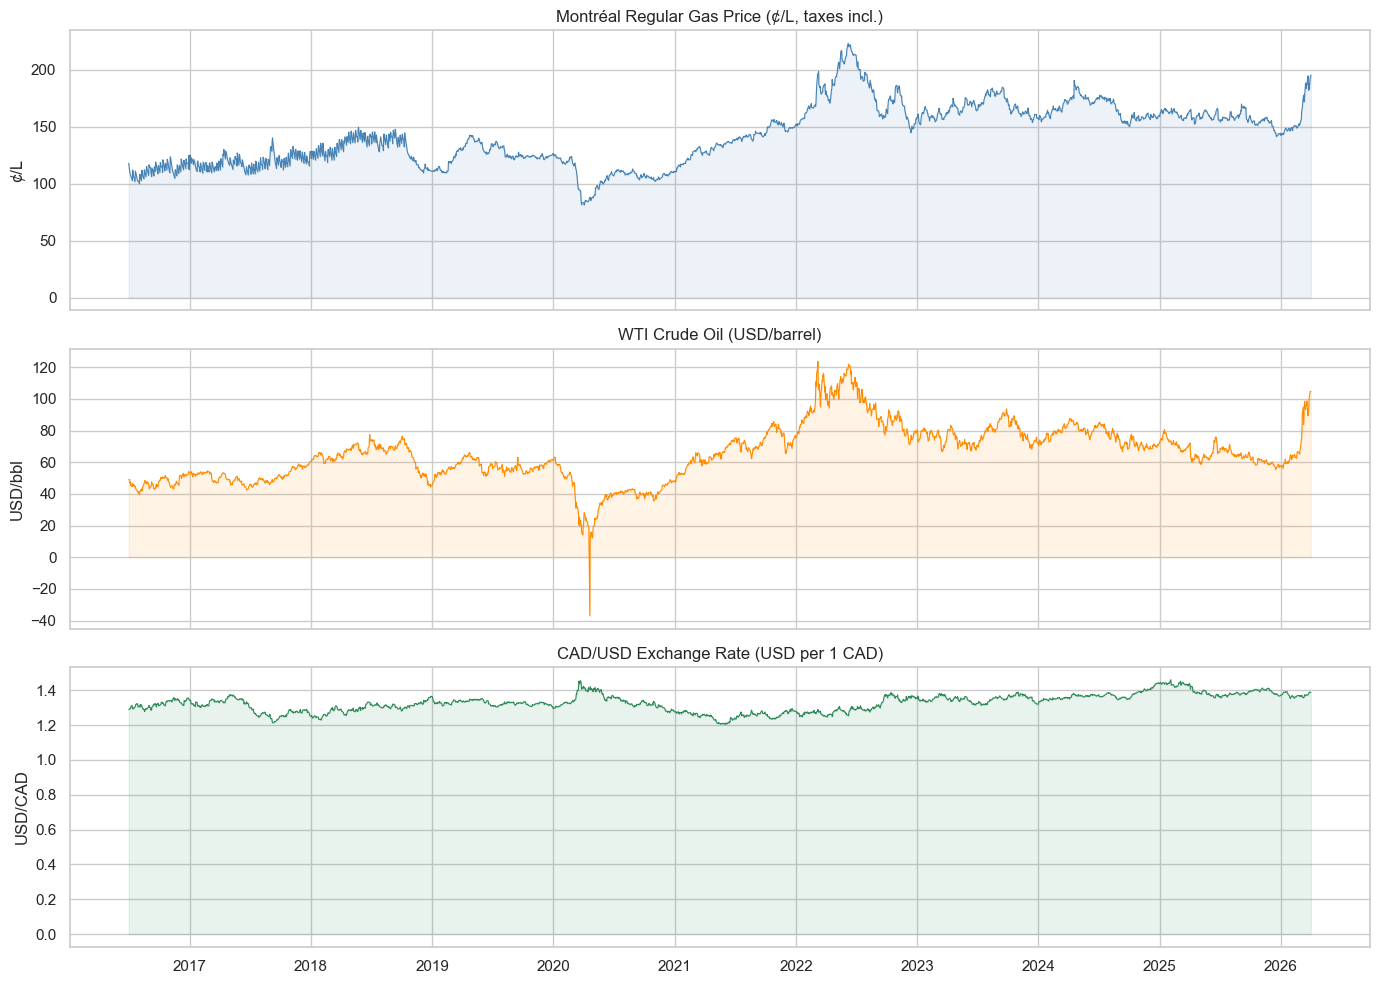

In [8]:
fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True)

axes[0].plot(df.index, df['gas_price'], color='steelblue', linewidth=0.8)
axes[0].fill_between(df.index, df['gas_price'], alpha=0.1, color='steelblue')
axes[0].set_title('Montréal Regular Gas Price (¢/L, taxes incl.)')
axes[0].set_ylabel('¢/L')

axes[1].plot(df.index, df['wti_usd'], color='darkorange', linewidth=0.8)
axes[1].fill_between(df.index, df['wti_usd'], alpha=0.1, color='darkorange')
axes[1].set_title('WTI Crude Oil (USD/barrel)')
axes[1].set_ylabel('USD/bbl')

axes[2].plot(df.index, df['cadusd'], color='seagreen', linewidth=0.8)
axes[2].fill_between(df.index, df['cadusd'], alpha=0.1, color='seagreen')
axes[2].set_title('CAD/USD Exchange Rate (USD per 1 CAD)')
axes[2].set_ylabel('USD/CAD')

axes[2].xaxis.set_major_locator(mdates.YearLocator())
axes[2].xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
plt.tight_layout()
plt.savefig(os.path.join(PLOTS_DIR, 'daily_series_overview.png'), dpi=150)
plt.show()

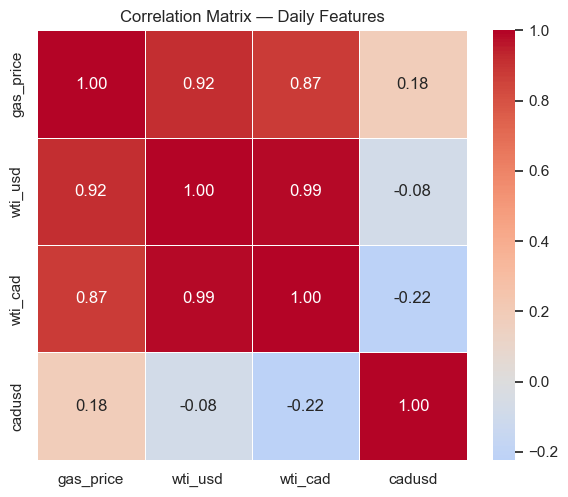

In [9]:
# Correlation heatmap
corr = df[['gas_price', 'wti_usd', 'wti_cad', 'cadusd']].corr()

plt.figure(figsize=(6, 5))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, square=True, linewidths=0.5)
plt.title('Correlation Matrix — Daily Features')
plt.tight_layout()
plt.show()

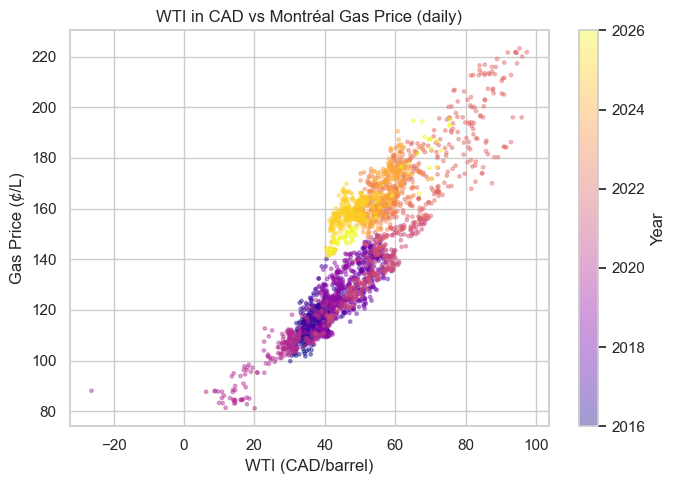

In [10]:
# Scatter: WTI (CAD) vs gas price — coloured by year
fig, ax = plt.subplots(figsize=(7, 5))
scatter = ax.scatter(df['wti_cad'], df['gas_price'],
                     c=df.index.year, cmap='plasma', alpha=0.4, s=6)
plt.colorbar(scatter, ax=ax, label='Year')
ax.set_xlabel('WTI (CAD/barrel)')
ax.set_ylabel('Gas Price (¢/L)')
ax.set_title('WTI in CAD vs Montréal Gas Price (daily)')
plt.tight_layout()
plt.show()

## 7. Save

In [11]:
df.to_csv(os.path.join(DATA_OUT_DIR, 'montreal_gas_features_daily.csv'), index_label='date')
print(f'Saved: ../Data/montreal_gas_features_daily.csv  ({len(df):,} rows x {df.shape[1]} columns)')
print('Columns:', df.columns.tolist())

Saved: ../Data/montreal_gas_features_daily.csv  (2,545 rows x 4 columns)
Columns: ['gas_price', 'wti_usd', 'cadusd', 'wti_cad']


## 8. What's in the dataset

| Column | Description |
|---|---|
| `gas_price` | Montréal retail regular gas, ¢/L, taxes included |
| `wti_usd` | WTI crude oil spot price, USD/barrel |
| `cadusd` | Exchange rate: USD per 1 CAD |
| `wti_cad` | WTI expressed in CAD/barrel (= wti_usd / cadusd) |

**Next:** Run Notebook 2 to build the ML feature matrix.